In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.weightstats import ttest_ind as sm_ttest_ind

plt.rcParams["figure.figsize"] = (8, 4)
sns.set(style="whitegrid")

In [2]:
cal = fetch_california_housing(as_frame=True)
df = cal.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
values = df["MedHouseVal"].values

population_mean = values.mean()
print("Approximate 'population' mean of MedHouseVal:", population_mean)

Approximate 'population' mean of MedHouseVal: 2.068558169089147


In [5]:
np.random.seed(0)  # for reproducibility
sample_100 = np.random.choice(values, size=100, replace=False)
sample_100_mean = sample_100.mean()

print("One random sample mean (n=100):", sample_100_mean)

One random sample mean (n=100): 2.0175302999999998


In [6]:
np.random.seed(0)
sample_means_100 = []

for i in range(1000):
    sample = np.random.choice(values, size=100, replace=False)
    sample_means_100.append(sample.mean())

len(sample_means_100), sample_means_100[:5]

(1000,
 [np.float64(2.0175302999999998),
  np.float64(2.1583303999999996),
  np.float64(2.1034204),
  np.float64(2.1594703999999996),
  np.float64(2.0644703)])

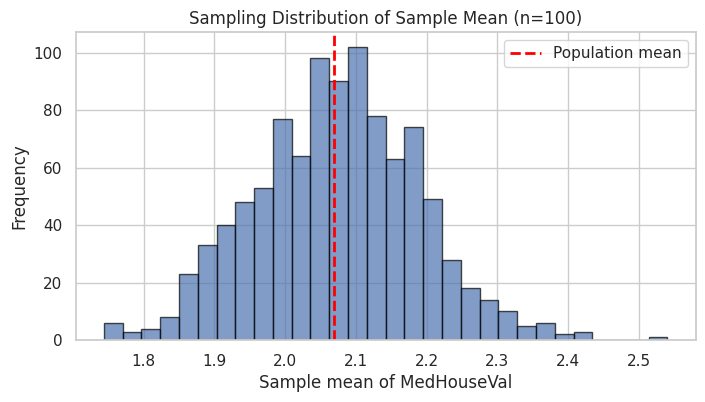

In [7]:
# Visualize the sampling distribution of the sample mean
plt.hist(sample_means_100, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(population_mean, color="red", linestyle="--", linewidth=2, label="Population mean")
plt.title("Sampling Distribution of Sample Mean (n=100)")
plt.xlabel("Sample mean of MedHouseVal")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Confidence Intervals and a One-Sample t-Test in Python

We will:
• Use a sample from MedHouseVal
• Build a 95% CI for the mean using a formula-based approach
• Perform a one-sample t-test on the same sample
• Interpret the p-value and the CI together

In [8]:
np.random.seed(42)
sample = np.random.choice(values, size=200, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)
n = len(sample)

print("Sample mean (n=200):", sample_mean)
print("Sample standard deviation:", sample_std)

Sample mean (n=200): 2.0415503
Sample standard deviation: 1.108409527646618


In [9]:
# 95% confidence interval for the mean using the t-distribution
alpha = 0.05
dfree = n - 1

sem = sample_std / np.sqrt(n)  # standard error of the mean
t_crit = stats.t.ppf(1 - alpha/2, df=dfree)

ci_low = sample_mean - t_crit * sem
ci_high = sample_mean + t_crit * sem

print("95% t-based CI for mean MedHouseVal:", (ci_low, ci_high))

95% t-based CI for mean MedHouseVal: (np.float64(1.8869954661400137), np.float64(2.196105133859986))


In [10]:
# One-sample t-test: test if mean MedHouseVal = 2.0 (i.e., $200,000)
hypothesized_mean = 2.0

t_stat, p_value = stats.ttest_1samp(sample, popmean=hypothesized_mean)

print("One-sample t-test against mean =", hypothesized_mean)
print("t-statistic:", t_stat)
print("p-value:", p_value)

One-sample t-test against mean = 2.0
t-statistic: 0.5301379708042787
p-value: 0.5966072961684321


In [11]:
n_bootstrap = 5000
bootstrap_means = []

np.random.seed(123)

for _ in range(n_bootstrap):
    resample = np.random.choice(sample, size=n, replace=True)
    bootstrap_means.append(resample.mean())

boot_ci_low = np.percentile(bootstrap_means, 2.5)
boot_ci_high = np.percentile(bootstrap_means, 97.5)

print("Bootstrap 95% CI for mean MedHouseVal:", (boot_ci_low, boot_ci_high))

Bootstrap 95% CI for mean MedHouseVal: (np.float64(1.8930732049999996), np.float64(2.2007213575))


<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

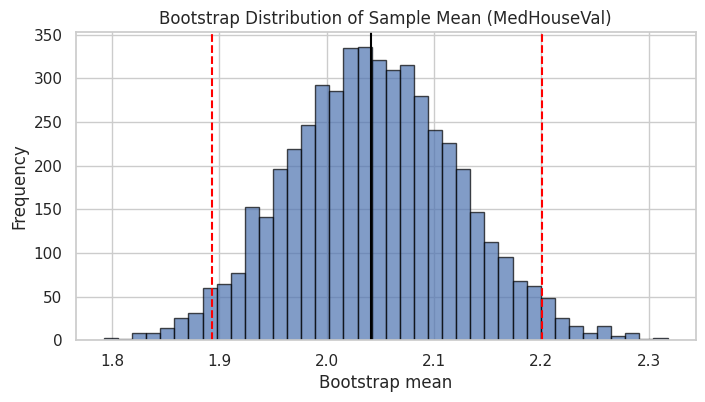

In [12]:
plt.hist(bootstrap_means, bins=40, edgecolor="black", alpha=0.7)
plt.axvline(boot_ci_low, color="red", linestyle="--", label="Bootstrap 2.5th percentile")
plt.axvline(boot_ci_high, color="red", linestyle="--", label="Bootstrap 97.5th percentile")
plt.axvline(sample_mean, color="black", linestyle="-", label="Original sample mean")
plt.title("Bootstrap Distribution of Sample Mean (MedHouseVal)")
plt.xlabel("Bootstrap mean")
plt.ylabel("Frequency")
plt.legend

In [13]:
# Create two groups by median income: low-income vs high-income districts
median_income = df["MedInc"].median()

low_income = df[df["MedInc"] <= median_income]["MedHouseVal"].values
high_income = df[df["MedInc"] > median_income]["MedHouseVal"].values

print("Low income group size:", len(low_income))
print("High income group size:", len(high_income))
print("Mean MedHouseVal (low income):", low_income.mean())
print("Mean MedHouseVal (high income):", high_income.mean())

Low income group size: 10320
High income group size: 10320
Mean MedHouseVal (low income): 1.4740195416666666
Mean MedHouseVal (high income): 2.6630967965116277


In [ ]:

# Two-sample t-test: compare mean MedHouseVal between low and high income groups
t_stat, p_value = stats.ttest_ind(high_income, low_income, equal_var=False)

print("Two-sample t-test (high vs low income):")
print("t-statistic:", t_stat)
print("p-value:", p_value)

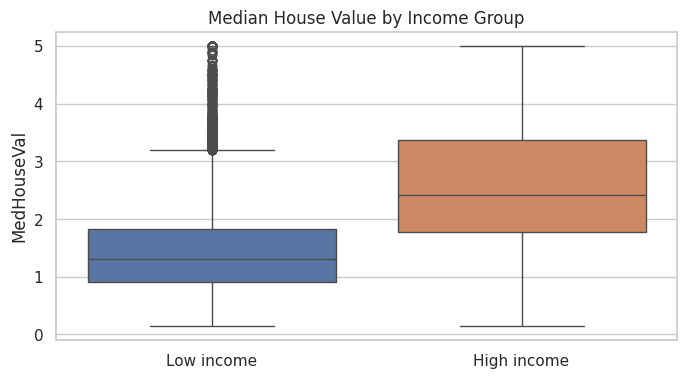

In [14]:
# Visualize the two groups
sns.boxplot(data=[low_income, high_income])
plt.xticks([0, 1], ["Low income", "High income"])
plt.ylabel("MedHouseVal")
plt.title("Median House Value by Income Group")
plt.show()

In [15]:
# Observed difference in mean MedHouseVal
obs_diff_income = high_income.mean() - low_income.mean()
print("Observed difference (high - low):", obs_diff_income)

Observed difference (high - low): 1.189077254844961


In [16]:
# Bootstrap the difference in mean MedHouseVal
n_bootstrap = 5000
boot_diffs_income = []

np.random.seed(2024)

for _ in range(n_bootstrap):
    # Resample WITH replacement within each group
    resample_low = np.random.choice(low_income, size=len(low_income), replace=True)
    resample_high = np.random.choice(high_income, size=len(high_income), replace=True)

    boot_diffs_income.append(resample_high.mean() - resample_low.mean())

len(boot_diffs_income), boot_diffs_income

(5000,
 [np.float64(1.2081204660852711),
  np.float64(1.1768712025193797),
  np.float64(1.1758849767441866),
  np.float64(1.1882538129844962),
  np.float64(1.1966385910852717),
  np.float64(1.192635270348837),
  np.float64(1.1792925125968994),
  np.float64(1.1993543633720933),
  np.float64(1.1793061812015506),
  np.float64(1.1819739418604651),
  np.float64(1.150493184108527),
  np.float64(1.1675336463178294),
  np.float64(1.1767988624031005),
  np.float64(1.1988479990310075),
  np.float64(1.2022832984496126),
  np.float64(1.2077114844961234),
  np.float64(1.1683224612403103),
  np.float64(1.197956971899225),
  np.float64(1.199319156007752),
  np.float64(1.1764933420542636),
  np.float64(1.1965398594961243),
  np.float64(1.217314990310077),
  np.float64(1.1803645164728682),
  np.float64(1.2051971463178295),
  np.float64(1.1998679273255812),
  np.float64(1.1853975503875966),
  np.float64(1.1842536782945738),
  np.float64(1.1903727790697676),
  np.float64(1.1830076802325582),
  np.float64

Bootstrap 95% CI for (high - low) mean MedHouseVal: (np.float64(1.162119967151163), np.float64(1.2155336592296515))


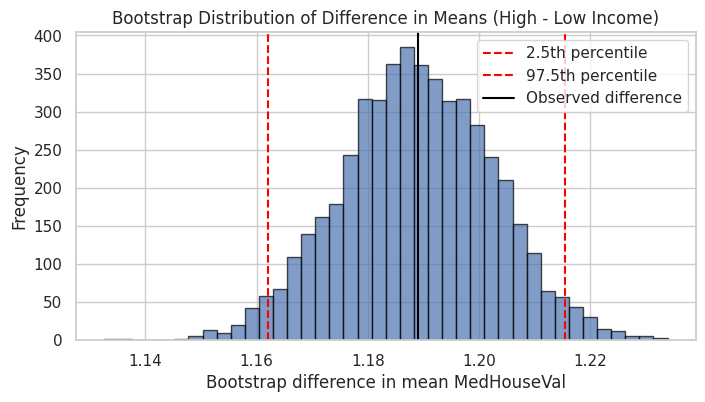

In [17]:
# 95% bootstrap CI for the difference
ci_low_income = np.percentile(boot_diffs_income, 2.5)
ci_high_income = np.percentile(boot_diffs_income, 97.5)

print("Bootstrap 95% CI for (high - low) mean MedHouseVal:", (ci_low_income, ci_high_income))

# Visualize bootstrap differences
plt.hist(boot_diffs_income, bins=40, edgecolor="black", alpha=0.7)
plt.axvline(ci_low_income, color="red", linestyle="--", label="2.5th percentile")
plt.axvline(ci_high_income, color="red", linestyle="--", label="97.5th percentile")
plt.axvline(obs_diff_income, color="black", linestyle="-", label="Observed difference")
plt.title("Bootstrap Distribution of Difference in Means (High - Low Income)")
plt.xlabel("Bootstrap difference in mean MedHouseVal")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [18]:
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

np.random.seed(999)

n_A = 500
n_B = 500

# Simulate conversions as 0/1 outcomes
conv_A = np.random.binomial(1, 0.12, n_A)
conv_B = np.random.binomial(1, 0.16, n_B)

mean_A = conv_A.mean()
mean_B = conv_B.mean()

print("Observed conversion rate A:", mean_A)
print("Observed conversion rate B:", mean_B)


Observed conversion rate A: 0.126
Observed conversion rate B: 0.156


In [19]:
# Two-sample t-test on the 0/1 outcomes (treating them as numeric)
t_stat_ab, p_value_ab = ttest_ind(conv_B, conv_A, equal_var=False)

print("Two-sample t-test (B vs A) on conversion:")
print("t-statistic:", t_stat_ab)
print("p-value:", p_value_ab)

Two-sample t-test (B vs A) on conversion:
t-statistic: 1.3628691347759656
p-value: 0.17323361923302938


In [20]:
# Optional: Proportion z-test for two samples
count = np.array([conv_B.sum(), conv_A.sum()])  # successes in each group
nobs = np.array([n_B, n_A])                    # number of observations in each group

z_stat, p_value_z = proportions_ztest(count, nobs)

print("Two-proportion z-test (B vs A):")
print("z-statistic:", z_stat)
print("p-value:", p_value_z)

Two-proportion z-test (B vs A):
z-statistic: 1.362966309370315
p-value: 0.1728931287836758


Observed difference in conversion (B - A): 0.03
Bootstrap 95% CI for (B - A) conversion rate: (np.float64(-0.014000000000000012), np.float64(0.07399999999999998))


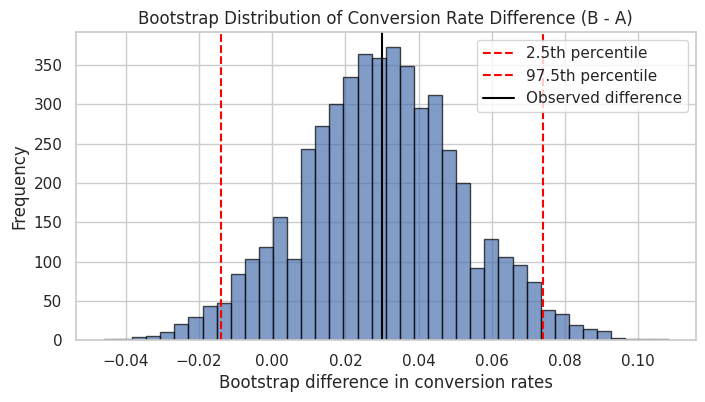

In [21]:
# Observed difference in conversion rates
obs_diff_conv = mean_B - mean_A
print("Observed difference in conversion (B - A):", obs_diff_conv)

# Bootstrap the difference in conversion rates
n_bootstrap = 5000
boot_diffs_conv = []

np.random.seed(2026)

for _ in range(n_bootstrap):
    # Resample WITH replacement within each group
    resample_A = np.random.choice(conv_A, size=n_A, replace=True)
    resample_B = np.random.choice(conv_B, size=n_B, replace=True)

    boot_diffs_conv.append(resample_B.mean() - resample_A.mean())

ci_low_conv = np.percentile(boot_diffs_conv, 2.5)
ci_high_conv = np.percentile(boot_diffs_conv, 97.5)

print("Bootstrap 95% CI for (B - A) conversion rate:", (ci_low_conv, ci_high_conv))

plt.hist(boot_diffs_conv, bins=40, edgecolor="black", alpha=0.7)
plt.axvline(ci_low_conv, color="red", linestyle="--", label="2.5th percentile")
plt.axvline(ci_high_conv, color="red", linestyle="--", label="97.5th percentile")
plt.axvline(obs_diff_conv, color="black", linestyle="-", label="Observed difference")
plt.title("Bootstrap Distribution of Conversion Rate Difference (B - A)")
plt.xlabel("Bootstrap difference in conversion rates")
plt.ylabel("Frequency")
plt.legend()
plt.show()


Today we:
• Used the California Housing dataset as a “population”

• Visualized sampling variability for the sample mean

• Built a t-based 95% CI and ran a one-sample t-test

• Applied bootstrap resampling to build CIs for the mean and median

• Compared two subgroups (low vs high income) with a two-sample t-test

• Bootstrapped the difference in MedHouseVal between income groups

• Simulated an A/B test with conversion data (12% vs 16%)

• Used a t-test and a two-proportion z-test to compare A and B

• Bootstrapped the difference in conversion rates for the A/B test